In [2]:
#question1... data cleaning and student analysis

#importing necessary python library
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np




In [3]:
#loading datasets
df = pd.read_csv("ai.intern_datasets.csv")
df.head(10)

,student_id,student_name,class,program,attendance_pct,assignment_score,exam_score,study_hours_per_day,lms_logins_per_week,course_completion_pct,quiz_average_pct,assignment_submission_rate_pct,days_since_last_login,fees_due,teacher_interactions_per_month,risk_level
0,STU1001,Student_1,Grade 11,Computer Science,80.8,81.3,90.1,1.6,3.7,61.5,56.1,38.5,1,No,2.5,Low
1,STU1002,Student_2,Grade 12,Science,100.0,66.3,94.5,3.4,2.4,99.8,71.3,75.1,2,No,5.6,Low
2,STU1003,Student_3,Grade 9,Science,89.3,81.5,68.5,2.1,6.0,64.3,84.6,80.6,11,No,5.8,Medium
3,STU1004,Student_4,Grade 11,Humanities,67.9,89.7,55.2,2.8,6.3,79.7,72.4,93.3,4,No,2.9,Medium
4,STU1005,Student_5,Grade 11,Computer Science,63.4,85.1,75.8,3.6,0.5,74.8,43.2,90.5,7,No,1.2,Low
5,STU1006,Student_6,Grade 12,Science,82.9,80.1,56.5,2.8,2.3,29.4,56.4,88.5,5,No,0.0,Low
6,STU1007,Student_7,Grade 9,Humanities,57.5,89.1,100.0,2.1,1.2,87.4,68.7,63.6,0,Yes,0.4,Low
7,STU1008,Student_8,Grade 9,Computer Science,100.0,90.7,70.3,2.6,2.9,76.3,68.7,43.7,5,No,0.5,Medium
8,STU1009,Student_9,Grade 11,Humanities,92.5,94.1,61.8,2.7,4.0,82.2,100.0,70.9,1,No,5.5,Low
9,STU1010,Student_10,Grade 10,Management,69.4,82.4,71.1,2.2,1.3,NaN,46.4,96.0,4,No,3.2,Low


In [5]:
#displaying number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 508
Number of columns: 16


In [6]:
#checking missing values
print("Missing Values:")
print(df.isnull().sum())


#checking duplicates data in datasets
print("Number of duplicate records:", df.duplicated().sum())

Missing Values:
student_id                         0
student_name                       0
class                              0
program                            0
attendance_pct                    15
assignment_score                  12
exam_score                         0
study_hours_per_day               11
lms_logins_per_week                0
course_completion_pct             11
quiz_average_pct                   0
assignment_submission_rate_pct     0
days_since_last_login              0
fees_due                           0
teacher_interactions_per_month     0
risk_level                         0
dtype: int64
Number of duplicate records: 8


In [8]:
#DATA_CLEANING
#now removing duplicate data
df = df.drop_duplicates().copy()

print("Dataset shape after removing duplicate data:", df.shape)

#filling missing data
missing_columns = [
    'attendance_pct',
    'assignment_score',
    'study_hours_per_day',
    'course_completion_pct'
]

for column in missing_columns:
    df[column] = df[column].fillna(df[column].median())

print(df.isnull().sum())

Dataset shape after removing duplicate data: (500, 16)
student_id                        0
student_name                      0
class                             0
program                           0
attendance_pct                    0
assignment_score                  0
exam_score                        0
study_hours_per_day               0
lms_logins_per_week               0
course_completion_pct             0
quiz_average_pct                  0
assignment_submission_rate_pct    0
days_since_last_login             0
fees_due                          0
teacher_interactions_per_month    0
risk_level                        0
dtype: int64


In [11]:
#calculating average values
print("Average Attendance:",round(df['attendance_pct'].mean(), 2))

print("Average Exam Score:",round(df['exam_score'].mean(), 2))

print("Average Assignment Score:",round(df['assignment_score'].mean(), 2))

print("Average Course Completion:",round(df['course_completion_pct'].mean(), 2))

Average Attendance: 75.78
Average Exam Score: 69.06
Average Assignment Score: 73.01
Average Course Completion: 71.43


In [12]:
#students with attendance below 60%
low_attendance = df[df['attendance_pct'] < 60]

print("Number of students with attendance below 60%:",
      len(low_attendance))

low_attendance[
    ['student_id', 'student_name', 'class',
     'program', 'attendance_pct', 'exam_score']
].head(20)

Number of students with attendance below 60%: 59


,student_id,student_name,class,program,attendance_pct,exam_score
6,STU1007,Student_7,Grade 9,Humanities,57.5,100.0
10,STU1011,Student_11,Grade 11,Science,52.0,45.1
14,STU1015,Student_15,Grade 12,Management,53.7,50.2
26,STU1027,Student_27,Grade 10,Computer Science,54.5,75.8
43,STU1044,Student_44,Grade 12,Management,51.4,63.3
44,STU1045,Student_45,Grade 12,Science,59.4,73.2
45,STU1046,Student_46,Grade 12,Humanities,47.5,81.9
51,STU1052,Student_52,Grade 10,Humanities,56.7,95.3
52,STU1053,Student_53,Grade 11,Science,52.2,76.3
56,STU1057,Student_57,Grade 12,Humanities,47.1,71.1


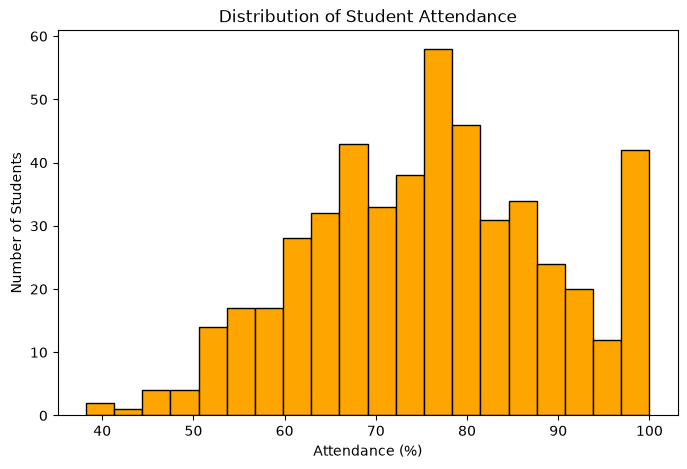

In [18]:
#Attendance distribution chart
plt.figure(figsize=(8, 5))

plt.hist(
    df['attendance_pct'],
    bins=20,
    edgecolor='black',
    color= 'orange'
)

plt.title("Distribution of Student Attendance")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.show()

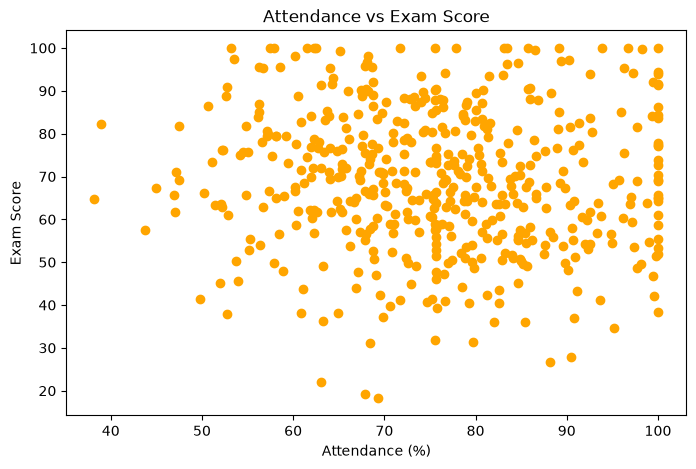

In [20]:
#Attendance VS Exam Score
plt.figure(figsize=(8, 5))

plt.scatter(
    df['attendance_pct'],
    df['exam_score'],
    color= 'orange'
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()




In [24]:
# question no.2 Student Risk Prediction


#selecting features
features = [
    'attendance_pct',
    'exam_score',
    'assignment_score',
    'lms_logins_per_week',
    'course_completion_pct'
]

X = df[features]
y = df['risk_level']

#spliting datasets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
   
)

#Training the classification model using logistic regression

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [25]:
#evaluating the model
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("Accuracy:", round(accuracy, 3))
print("Weighted F1-score:", round(weighted_f1, 3))
print("Macro F1-score:", round(macro_f1, 3))

Accuracy: 0.58
Weighted F1-score: 0.615
Macro F1-score: 0.386


In [27]:
#question no.3... students attendance analysis
#1. students attendance below 60%
low_attendance = df[df['attendance_pct'] < 60]

print("Number of students below 60%:",
      len(low_attendance))

low_attendance[
    ['student_id',
     'student_name',
     'attendance_pct',
     'exam_score']
]


Number of students below 60%: 59


,student_id,student_name,attendance_pct,exam_score
6,STU1007,Student_7,57.5,100.0
10,STU1011,Student_11,52.0,45.1
14,STU1015,Student_15,53.7,50.2
26,STU1027,Student_27,54.5,75.8
43,STU1044,Student_44,51.4,63.3
44,STU1045,Student_45,59.4,73.2
45,STU1046,Student_46,47.5,81.9
51,STU1052,Student_52,56.7,95.3
52,STU1053,Student_53,52.2,76.3
56,STU1057,Student_57,47.1,71.1


In [29]:
#2. average attendance by class
class_attendance = (
    df.groupby('class')['attendance_pct']
      .mean()
)

print(class_attendance.round(2))

#attendance by program
program_attendance = (
    df.groupby('program')['attendance_pct']
      .mean()
      .sort_values()
)

print(program_attendance.round(2))

class
Grade 10    76.35
Grade 11    74.89
Grade 12    75.31
Grade 9     76.73
Name: attendance_pct, dtype: float64
program
Computer Science    74.57
Humanities          75.87
Management          76.19
Science             76.31
Name: attendance_pct, dtype: float64


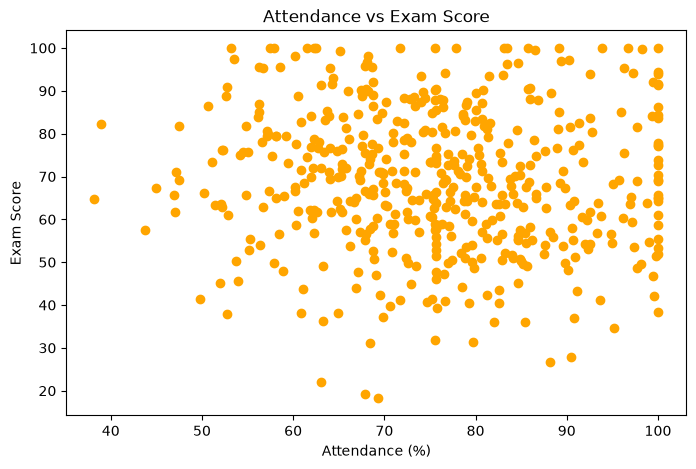

In [32]:
#chart of attendance vs exam score
plt.figure(figsize=(8, 5))

plt.scatter(
    df['attendance_pct'],
    df['exam_score'],
    color= 'orange'
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

In [33]:
#creating attendance status
def attendance_status(attendance):
    if attendance >= 80:
        return "Good"
    elif attendance >= 60:
        return "Average"
    else:
        return "Low"

df['attendance_status'] = (
    df['attendance_pct']
    .apply(attendance_status)
)

df[
    ['student_id',
     'attendance_pct',
     'attendance_status']
].head(10)

,student_id,attendance_pct,attendance_status
0,STU1001,80.8,Good
1,STU1002,100.0,Good
2,STU1003,89.3,Good
3,STU1004,67.9,Average
4,STU1005,63.4,Average
5,STU1006,82.9,Good
6,STU1007,57.5,Low
7,STU1008,100.0,Good
8,STU1009,92.5,Good
9,STU1010,69.4,Average


In [35]:
#question no.4 ... Simple students analytics dashboard

#dashboard key performancce indicator
total_students = len(df)

average_attendance = df['attendance_pct'].mean()
average_exam_score = df['exam_score'].mean()
average_completion = df['course_completion_pct'].mean()

print("Total Students:", total_students)
print("Average Attendance:", round(average_attendance, 2))
print("Average Exam Score:", round(average_exam_score, 2))
print("Average Course Completion:", round(average_completion, 2))

#distributing risk level
risk_counts = df['risk_level'].value_counts()

print(risk_counts)

Total Students: 500
Average Attendance: 75.78
Average Exam Score: 69.06
Average Course Completion: 71.43
risk_level
Low       314
Medium    182
High        4
Name: count, dtype: int64


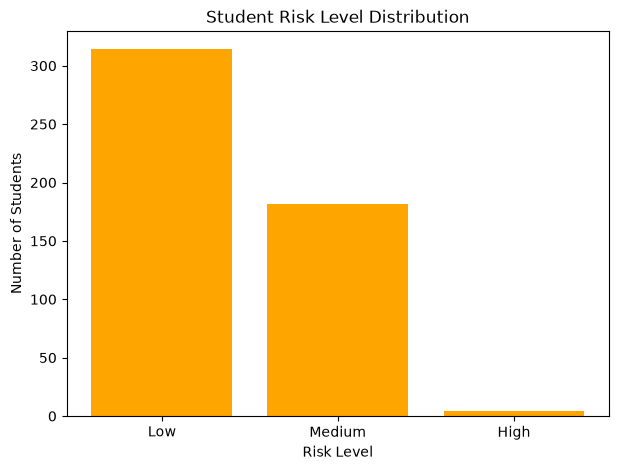

In [38]:
#students risk distribution chart

risk_counts = df['risk_level'].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values,
    color='orange'
)

plt.title("Student Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")

plt.show()

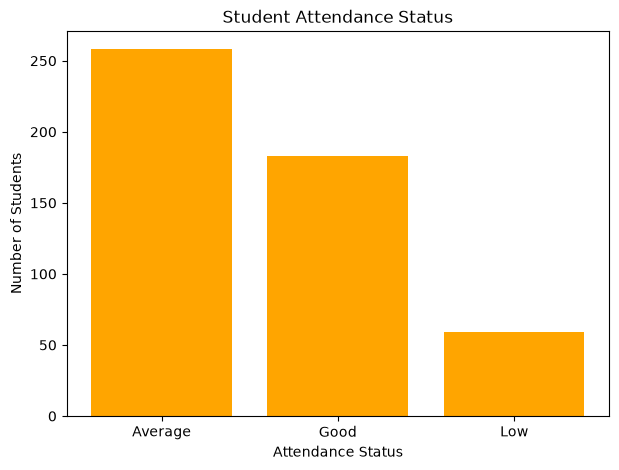

In [39]:
#chart of Attendance Status Distribution

attendance_counts = df['attendance_status'].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    attendance_counts.index,
    attendance_counts.values,
    color= 'orange'
)

plt.title("Student Attendance Status")
plt.xlabel("Attendance Status")
plt.ylabel("Number of Students")

plt.show()

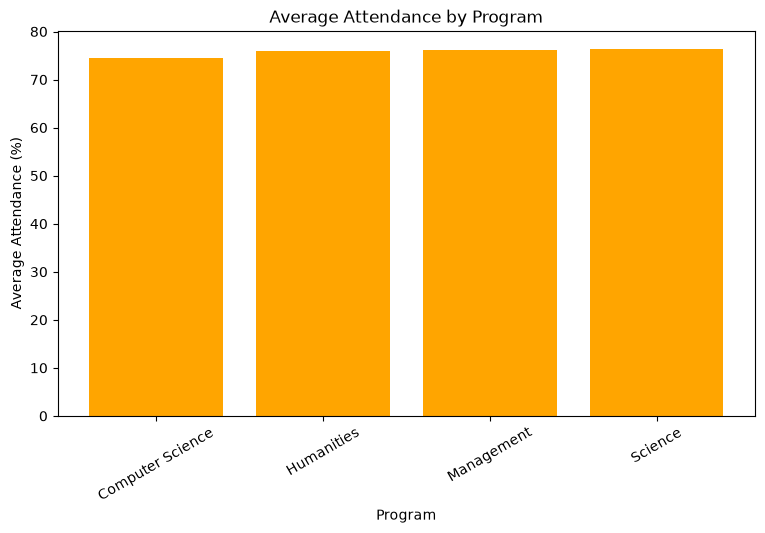

In [40]:
#chart of Average Attendance by Program

program_avg = (
    df.groupby('program')['attendance_pct']
      .mean()
      .sort_values()
)

plt.figure(figsize=(9, 5))

plt.bar(
    program_avg.index,
    program_avg.values,
    color= 'orange'
)

plt.title("Average Attendance by Program")
plt.xlabel("Program")
plt.ylabel("Average Attendance (%)")

plt.xticks(rotation=30)

plt.show()